# Exercício 12 — Motor de indexação e consulta com estruturas combinadas

Aluno: Henrique Goldstein Maluhy Mendes Amaral · DR1_AT · Infnet

Para rodar: Ambiente de execução → Executar tudo.

In [1]:
import random
import time
import unicodedata

import matplotlib.pyplot as plt
import pandas as pd

random.seed(42)

## 1. Documentos e tokenização

Os documentos ficam no próprio notebook. Na tokenização passo o texto para minúsculas, tiro os acentos (para "binária" e "binaria" serem o mesmo termo), separo por tudo que não é letra ou número e descarto palavras muito comuns, como artigos e preposições.

In [2]:
DOCUMENTOS = [
    "A busca binária divide o vetor ordenado ao meio a cada passo.",
    "A busca linear percorre a lista elemento por elemento até achar o valor.",
    "Uma lista encadeada guarda cada valor em um nó que aponta para o próximo nó.",
    "A pilha segue a regra: o último a entrar é o primeiro a sair.",
    "A fila segue a regra: o primeiro a entrar é o primeiro a sair.",
    "A tabela hash usa uma função hash para achar o bucket de cada chave.",
    "Colisões na tabela hash podem ser tratadas com uma lista encadeada em cada bucket.",
    "A árvore binária de busca guarda as chaves menores à esquerda e as maiores à direita.",
    "O quicksort escolhe um pivô e divide o vetor em menores e maiores que ele.",
    "A programação dinâmica guarda o resultado dos subproblemas para não recalcular.",
    "A recursão resolve o problema chamando a própria função num caso menor.",
    "Ordenar o vetor permite trocar a busca linear pela busca binária.",
]

PALAVRAS_VAZIAS = {"a", "o", "as", "os", "de", "da", "do", "das", "dos", "e", "em", "um", "uma",
                   "para", "com", "que", "no", "na", "num", "ao", "por", "pela", "pelo", "se", "ser", "ele", "cada"}


def normalizar(texto):
    sem_acento = unicodedata.normalize("NFD", texto.lower())
    return "".join(c for c in sem_acento if unicodedata.category(c) != "Mn")


def tokenizar(texto):
    """Devolve a lista de termos normalizados, na ordem em que aparecem."""
    termos, atual = [], ""
    for caractere in normalizar(texto) + " ":
        if caractere.isalnum():
            atual += caractere
        else:
            if atual and atual not in PALAVRAS_VAZIAS:
                termos.append(atual)
            atual = ""
    return termos


print(tokenizar(DOCUMENTOS[0]))
print(tokenizar(DOCUMENTOS[7]))

['busca', 'binaria', 'divide', 'vetor', 'ordenado', 'meio', 'passo']
['arvore', 'binaria', 'busca', 'guarda', 'chaves', 'menores', 'esquerda', 'maiores', 'direita']


## 2. As estruturas

### Lista encadeada de ocorrências

Cada termo tem uma lista encadeada de ocorrências `(doc_id, posições)`, com tail para anexar no fim em O(1). Como os documentos são indexados em ordem de `doc_id`, as listas já saem ordenadas por `doc_id`, e isso permite as consultas eficientes da seção 6.

In [3]:
class NoOcorrencia:
    def __init__(self, doc_id, posicoes):
        self.value = (doc_id, posicoes)
        self.next = None


class ListaOcorrencias:
    def __init__(self):
        self.head = None
        self.tail = None
        self.size = 0

    def insert_last(self, doc_id, posicoes):
        novo = NoOcorrencia(doc_id, posicoes)
        if self.head is None:
            self.head = novo
        else:
            self.tail.next = novo
        self.tail = novo
        self.size += 1

    def __iter__(self):
        atual = self.head
        while atual is not None:
            yield atual.value
            atual = atual.next

    def doc_ids(self):
        return [doc_id for doc_id, _ in self]

### Tabela hash com encadeamento

A mesma do exercício 4, com hash próprio para os números saírem iguais em toda execução. Aceita strings e tuplas (as tuplas são usadas no memo da seção 8).

In [4]:
class NoBucket:
    def __init__(self, key, value):
        self.key = key
        self.value = value
        self.next = None


class HashTableChained:
    LIMIAR = 0.75

    def __init__(self, capacidade=8):
        self.capacidade = capacidade
        self.buckets = [None] * capacidade
        self.quantidade = 0
        self.comparacoes = 0

    def _funcao_hash(self, key):
        if isinstance(key, int):
            return key
        if isinstance(key, tuple):
            h = 0
            for parte in key:
                h = (h * 1_000_003 + self._funcao_hash(parte)) % (2**32)
            return h
        h = 0
        for caractere in key:
            h = (h * 31 + ord(caractere)) % (2**32)
        return h

    def _indice(self, key):
        return self._funcao_hash(key) % self.capacidade

    def put(self, key, value):
        i = self._indice(key)
        atual = self.buckets[i]
        while atual is not None:
            self.comparacoes += 1
            if atual.key == key:
                atual.value = value
                return
            atual = atual.next
        novo = NoBucket(key, value)
        novo.next = self.buckets[i]
        self.buckets[i] = novo
        self.quantidade += 1
        if self.quantidade / self.capacidade > self.LIMIAR:
            self._rehash()

    def get(self, key, padrao=None):
        atual = self.buckets[self._indice(key)]
        while atual is not None:
            self.comparacoes += 1
            if atual.key == key:
                return atual.value
            atual = atual.next
        return padrao

    def __len__(self):
        return self.quantidade

    def _rehash(self):
        antigos = self.buckets
        self.capacidade *= 2
        self.buckets = [None] * self.capacidade
        for cabeca in antigos:
            atual = cabeca
            while atual is not None:
                proximo = atual.next
                i = self._indice(atual.key)
                atual.next = self.buckets[i]
                self.buckets[i] = atual
                atual = proximo

### BST de termos

Para listar o vocabulário em ordem e buscar um termo. Inserção, busca e in-order são recursivas; a altura aqui é pequena, então não há risco com o limite de recursão.

In [5]:
class NoTermo:
    def __init__(self, termo):
        self.termo = termo
        self.esquerda = None
        self.direita = None


class BSTTermos:
    def __init__(self):
        self.raiz = None
        self.tamanho = 0

    def insert(self, termo):
        self.raiz = self._inserir(self.raiz, termo)

    def _inserir(self, no, termo):
        if no is None:
            self.tamanho += 1
            return NoTermo(termo)
        if termo < no.termo:
            no.esquerda = self._inserir(no.esquerda, termo)
        elif termo > no.termo:
            no.direita = self._inserir(no.direita, termo)
        return no                              # termo repetido: não insere de novo

    def search(self, termo):
        """Devolve (achou, comparações)."""
        return self._buscar(self.raiz, termo, 0)

    def _buscar(self, no, termo, comparacoes):
        if no is None:
            return False, comparacoes
        if termo == no.termo:
            return True, comparacoes + 1
        proximo = no.esquerda if termo < no.termo else no.direita
        return self._buscar(proximo, termo, comparacoes + 1)

    def in_order(self):
        termos = []
        self._em_ordem(self.raiz, termos)
        return termos

    def _em_ordem(self, no, termos):
        if no is not None:
            self._em_ordem(no.esquerda, termos)
            termos.append(no.termo)
            self._em_ordem(no.direita, termos)

### Pilha e fila

A pilha é usada na conversão da consulta para pós-fixa e na avaliação. A fila é por encadeamento (como na aula de pilhas e filas por encadeamento) e é usada na travessia em largura da BST.

In [6]:
class Stack:
    def __init__(self):
        self.itens = []

    def push(self, item):
        self.itens.append(item)

    def pop(self):
        if not self.itens:
            raise IndexError("pop em pilha vazia")
        return self.itens.pop()

    def peek(self):
        return self.itens[-1] if self.itens else None

    def is_empty(self):
        return not self.itens

    def __len__(self):
        return len(self.itens)


class NoFila:
    def __init__(self, valor):
        self.valor = valor
        self.prox = None


class Queue:
    def __init__(self):
        self.inicio = None
        self.fim = None
        self.tamanho = 0

    def enqueue(self, valor):
        novo = NoFila(valor)
        if self.fim is None:
            self.inicio = novo
        else:
            self.fim.prox = novo
        self.fim = novo
        self.tamanho += 1

    def dequeue(self):
        if self.inicio is None:
            raise IndexError("dequeue em fila vazia")
        valor = self.inicio.valor
        self.inicio = self.inicio.prox
        if self.inicio is None:
            self.fim = None
        self.tamanho -= 1
        return valor

    def is_empty(self):
        return self.inicio is None

## 3. A indexação

Para cada documento: tokenizo, junto as posições de cada termo e anexo `(doc_id, posições)` no fim da lista do termo. Um termo novo também entra na BST.

In [7]:
class IndiceInvertido:
    def __init__(self, documentos):
        self.documentos = documentos
        self.tabela = HashTableChained()
        self.termos = BSTTermos()
        self.total_tokens = 0
        for doc_id, texto in enumerate(documentos):
            self._indexar(doc_id, texto)

    def _indexar(self, doc_id, texto):
        posicoes_no_doc = HashTableChained()      # termo → posições dentro deste documento
        ordem = []                                # termos na ordem em que apareceram
        for posicao, termo in enumerate(tokenizar(texto)):
            self.total_tokens += 1
            posicoes = posicoes_no_doc.get(termo)
            if posicoes is None:
                posicoes = []
                posicoes_no_doc.put(termo, posicoes)
                ordem.append(termo)
            posicoes.append(posicao)
        for termo in ordem:
            lista = self.tabela.get(termo)
            if lista is None:
                lista = ListaOcorrencias()
                self.tabela.put(termo, lista)
                self.termos.insert(termo)          # termo novo no vocabulário
            lista.insert_last(doc_id, posicoes_no_doc.get(termo))

    def ocorrencias(self, termo):
        return self.tabela.get(termo) or ListaOcorrencias()

    def doc_ids(self, termo):
        return self.ocorrencias(termo).doc_ids()


indice = IndiceInvertido(DOCUMENTOS)
print(f"{len(DOCUMENTOS)} documentos, {indice.total_tokens} termos indexados, "
      f"vocabulário de {indice.termos.tamanho} termos distintos\n")
for termo in ["busca", "hash", "lista", "encadeada", "vetor"]:
    print(f"{termo:<10} → {list(indice.ocorrencias(termo))}")

12 documentos, 91 termos indexados, vocabulário de 60 termos distintos

busca      → [(0, [0]), (1, [0]), (7, [2]), (11, [4, 6])]
hash       → [(5, [1, 4]), (6, [2])]
lista      → [(1, [3]), (2, [0]), (6, [5])]
encadeada  → [(2, [1]), (6, [6])]
vetor      → [(0, [3]), (8, [4]), (11, [1])]


Cada linha é `(doc_id, [posições])`. Confiro o índice contra uma contagem feita da forma mais direta possível:

In [8]:
vocabulario = indice.termos.in_order()
for termo in vocabulario:
    esperado = []
    for doc_id, texto in enumerate(DOCUMENTOS):
        posicoes = [p for p, t in enumerate(tokenizar(texto)) if t == termo]
        if posicoes:
            esperado.append((doc_id, posicoes))
    assert list(indice.ocorrencias(termo)) == esperado, termo
    ids = indice.doc_ids(termo)
    assert ids == sorted(ids)                      # ordenada por doc_id, sem esforço extra
print(f"os {len(vocabulario)} termos conferidos: ocorrências corretas e listas ordenadas por doc_id")

os 60 termos conferidos: ocorrências corretas e listas ordenadas por doc_id


## 4. BST de termos: listagem ordenada e busca

In [9]:
print("vocabulário em ordem alfabética (in-order):\n")
print(", ".join(vocabulario))
assert vocabulario == sorted(vocabulario)

print()
for termo in ["recursao", "quicksort", "grafo"]:
    achou, comparacoes = indice.termos.search(termo)
    print(f"busca por '{termo}': {'achou' if achou else 'não existe'} com {comparacoes} comparações")

vocabulário em ordem alfabética (in-order):

achar, aponta, arvore, ate, binaria, bucket, busca, caso, chamando, chave, chaves, colisoes, dinamica, direita, divide, elemento, encadeada, entrar, escolhe, esquerda, fila, funcao, guarda, hash, linear, lista, maiores, meio, menor, menores, nao, ordenado, ordenar, passo, percorre, permite, pilha, pivo, podem, primeiro, problema, programacao, propria, proximo, quicksort, recalcular, recursao, regra, resolve, resultado, sair, segue, subproblemas, tabela, tratadas, trocar, ultimo, usa, valor, vetor

busca por 'recursao': achou com 13 comparações
busca por 'quicksort': achou com 11 comparações
busca por 'grafo': não existe com 12 comparações


## 5. Diagnóstico da BST com travessia em largura

A BFS visita a árvore nível por nível usando a fila. O relatório mostra os termos de cada nível, a altura, a altura mínima possível e a altura de cada lado da raiz.

In [10]:
def altura(no):
    if no is None:
        return 0
    return 1 + max(altura(no.esquerda), altura(no.direita))


def relatorio_bfs(bst):
    fila = Queue()
    fila.enqueue((bst.raiz, 0))
    por_nivel = []
    while not fila.is_empty():
        no, nivel = fila.dequeue()
        if no is None:
            continue
        if nivel == len(por_nivel):
            por_nivel.append([])
        por_nivel[nivel].append(no.termo)
        fila.enqueue((no.esquerda, nivel + 1))
        fila.enqueue((no.direita, nivel + 1))

    n = bst.tamanho
    minima = n.bit_length()                        # ⌈log2(n + 1)⌉: altura da árvore mais cheia possível
    return {
        "termos": n,
        "altura": len(por_nivel),
        "altura_minima": minima,
        "altura / minima": len(por_nivel) / minima,
        "altura_esquerda_da_raiz": altura(bst.raiz.esquerda),
        "altura_direita_da_raiz": altura(bst.raiz.direita),
        "por_nivel": por_nivel,
    }


diag = relatorio_bfs(indice.termos)
print(f"raiz: '{indice.termos.raiz.termo}' · {diag['termos']} termos · altura {diag['altura']} "
      f"(mínima possível: {diag['altura_minima']}) · razão {diag['altura / minima']:.2f}")
print(f"subárvore esquerda com altura {diag['altura_esquerda_da_raiz']}, "
      f"direita com {diag['altura_direita_da_raiz']}\n")
for nivel, termos in enumerate(diag["por_nivel"]):
    print(f"nível {nivel:>2} ({len(termos):>2} termos): {', '.join(termos)}")

raiz: 'busca' · 60 termos · altura 13 (mínima possível: 6) · razão 2.17
subárvore esquerda com altura 5, direita com 12

nível  0 ( 1 termos): busca
nível  1 ( 2 termos): binaria, divide
nível  2 ( 4 termos): ate, bucket, chave, vetor
nível  3 ( 4 termos): achar, chamando, colisoes, ordenado
nível  4 ( 6 termos): aponta, caso, chaves, direita, meio, passo
nível  5 ( 6 termos): arvore, dinamica, linear, menores, ordenar, percorre
nível  6 ( 5 termos): elemento, lista, menor, nao, valor
nível  7 ( 3 termos): encadeada, maiores, proximo
nível  8 ( 3 termos): guarda, pilha, segue
nível  9 ( 6 termos): entrar, hash, permite, primeiro, regra, ultimo
nível 10 ( 7 termos): fila, podem, programacao, quicksort, sair, tabela, usa
nível 11 ( 9 termos): esquerda, funcao, pivo, problema, propria, recalcular, resultado, subproblemas, tratadas
nível 12 ( 4 termos): escolhe, recursao, resolve, trocar


A altura ficou perto do dobro da mínima, o esperado para uma BST sem balanceamento. A raiz está desequilibrada: o primeiro termo inserido foi "busca", que começa com b, então quase todo o vocabulário foi para a direita.

## 6. Consultas booleanas

1. Separo a consulta em parênteses, operadores (AND, OR e NOT, em maiúsculas) e termos.
2. Converto para pós-fixa com o shunting-yard, usando a pilha (precedência NOT > AND > OR; o NOT é unário).
3. Avalio a pós-fixa com a pilha: um termo empilha a sua lista de doc_ids; um operador desempilha, combina e empilha o resultado.

Como as listas estão ordenadas, AND e OR andam com dois ponteiros, em O(m + n).

In [11]:
class ConsultaInvalidaError(Exception):
    """A consulta não pode ser interpretada."""


PRECEDENCIA = {"NOT": 3, "AND": 2, "OR": 1}


def tokens_da_consulta(consulta):
    tokens, atual = [], ""
    for caractere in consulta + " ":
        if caractere in "() ":
            if atual:
                tokens.append(atual if atual in PRECEDENCIA else normalizar(atual))
                atual = ""
            if caractere != " ":
                tokens.append(caractere)
        else:
            atual += caractere
    if not tokens:
        raise ConsultaInvalidaError("consulta vazia")
    return tokens


def para_posfixa(tokens):
    saida, pilha = [], Stack()
    anterior = None                          # para detectar dois termos seguidos sem operador
    for posicao, token in enumerate(tokens, start=1):
        if token == "(":
            pilha.push(token)
        elif token == ")":
            while not pilha.is_empty() and pilha.peek() != "(":
                saida.append(pilha.pop())
            if pilha.is_empty():
                raise ConsultaInvalidaError(f"')' na posição {posicao} não tem '(' correspondente")
            pilha.pop()                      # descarta o '('
        elif token in PRECEDENCIA:
            # desempilha operadores de precedência maior (ou igual, se não for o NOT)
            while (not pilha.is_empty() and pilha.peek() in PRECEDENCIA and token != "NOT"
                   and PRECEDENCIA[pilha.peek()] >= PRECEDENCIA[token]):
                saida.append(pilha.pop())
            pilha.push(token)
        else:
            if anterior is not None and anterior not in PRECEDENCIA and anterior != "(":
                raise ConsultaInvalidaError(
                    f"falta um operador entre '{anterior}' e '{token}' (posição {posicao})")
            saida.append(token)
        anterior = token
    while not pilha.is_empty():
        topo = pilha.pop()
        if topo == "(":
            raise ConsultaInvalidaError("tem '(' sem o ')' correspondente")
        saida.append(topo)
    return saida


def intersecao(a, b, cont):
    """AND em listas ordenadas: dois ponteiros, O(m + n)."""
    i = j = 0
    resultado = []
    while i < len(a) and j < len(b):
        cont["comparacoes"] += 1
        if a[i] == b[j]:
            resultado.append(a[i])
            i += 1
            j += 1
        elif a[i] < b[j]:
            i += 1
        else:
            j += 1
    return resultado


def uniao(a, b, cont):
    """OR em listas ordenadas: intercalação sem repetir, O(m + n)."""
    i = j = 0
    resultado = []
    while i < len(a) and j < len(b):
        cont["comparacoes"] += 1
        if a[i] == b[j]:
            resultado.append(a[i])
            i += 1
            j += 1
        elif a[i] < b[j]:
            resultado.append(a[i])
            i += 1
        else:
            resultado.append(b[j])
            j += 1
    return resultado + a[i:] + b[j:]


def diferenca(todos, a, cont):
    """NOT: todos os documentos menos os de `a`, também com dois ponteiros."""
    resultado, j = [], 0
    for doc in todos:
        while j < len(a) and a[j] < doc:
            cont["comparacoes"] += 1
            j += 1
        if j < len(a) and a[j] == doc:
            cont["comparacoes"] += 1
            continue
        resultado.append(doc)
    return resultado


def avaliar(posfixa, indice, cont):
    pilha = Stack()
    todos = list(range(len(indice.documentos)))
    for token in posfixa:
        if token == "NOT":
            if pilha.is_empty():
                raise ConsultaInvalidaError("NOT sem termo depois dele")
            pilha.push(diferenca(todos, pilha.pop(), cont))
        elif token in ("AND", "OR"):
            if len(pilha) < 2:
                raise ConsultaInvalidaError(f"{token} precisa de um termo de cada lado")
            b, a = pilha.pop(), pilha.pop()
            pilha.push(intersecao(a, b, cont) if token == "AND" else uniao(a, b, cont))
        else:
            pilha.push(indice.doc_ids(token))
    if len(pilha) != 1:
        raise ConsultaInvalidaError("sobraram termos sem operador entre eles")
    return pilha.pop()


def consultar(consulta, indice):
    cont = {"comparacoes": 0}
    posfixa = para_posfixa(tokens_da_consulta(consulta))
    return avaliar(posfixa, indice, cont), posfixa, cont["comparacoes"]


for consulta in ["busca AND binaria",
                 "busca AND NOT binaria",
                 "(pilha OR fila) AND regra",
                 "hash AND NOT (lista OR encadeada)",
                 "vetor AND (quicksort OR busca) AND NOT linear",
                 "NOT NOT arvore"]:
    docs, posfixa, comparacoes = consultar(consulta, indice)
    print(f"{consulta:<45} → docs {docs}")
    print(f"{'':<45}   pós-fixa: {' '.join(posfixa)}  ({comparacoes} comparações)\n")

busca AND binaria                             → docs [0, 7, 11]
                                                pós-fixa: busca binaria AND  (4 comparações)

busca AND NOT binaria                         → docs [1]
                                                pós-fixa: busca binaria NOT AND  (16 comparações)

(pilha OR fila) AND regra                     → docs [3, 4]
                                                pós-fixa: pilha fila OR regra AND  (3 comparações)

hash AND NOT (lista OR encadeada)             → docs [5]
                                                pós-fixa: hash lista encadeada OR NOT AND  (14 comparações)

vetor AND (quicksort OR busca) AND NOT linear → docs [0, 8]
                                                pós-fixa: vetor quicksort busca OR AND linear NOT AND  (22 comparações)

NOT NOT arvore                                → docs [7]
                                                pós-fixa: arvore NOT NOT  (23 comparações)



Confiro as consultas contra uma avaliação documento por documento (as operações de conjunto do Python aparecem só como gabarito):

In [12]:
def gabarito(consulta):
    termos_por_doc = [set(tokenizar(t)) for t in DOCUMENTOS]
    expressao = []
    for token in tokens_da_consulta(consulta):
        if token in ("AND", "OR", "NOT"):
            expressao.append(token.lower())
        elif token in "()":
            expressao.append(token)
        else:
            expressao.append(f"({token!r} in termos)")
    codigo = " ".join(expressao)
    return [d for d, termos in enumerate(termos_por_doc) if eval(codigo, {}, {"termos": termos})]


for consulta in ["busca AND binaria", "busca OR vetor", "NOT hash", "(pilha OR fila) AND NOT primeiro",
                 "hash AND NOT (lista OR encadeada)", "NOT (busca OR lista) AND NOT vetor",
                 "arvore OR recursao OR quicksort", "NOT NOT arvore", "inexistente OR fila"]:
    assert consultar(consulta, indice)[0] == gabarito(consulta), consulta
print("9 consultas conferidas contra a avaliação documento a documento")

9 consultas conferidas contra a avaliação documento a documento


## 7. Ranqueamento com QuickSort

A pontuação de cada documento usa os termos da consulta que não vêm logo depois de um NOT: +1 para cada ocorrência do termo e + 1/(1 + primeira posição), para valorizar termos que aparecem no começo do texto. Os pontos são calculados numa passada só por lista de ocorrências. A ordenação usa um QuickSort recursivo em três listas, como na aula, com pivô sorteado e contando as comparações.

In [13]:
def termos_positivos(consulta):
    tokens = tokens_da_consulta(consulta)
    positivos = []
    for i, token in enumerate(tokens):
        if token not in PRECEDENCIA and token not in "()" and (i == 0 or tokens[i - 1] != "NOT"):
            positivos.append(token)
    return positivos


def pontuar_todos(docs, termos, indice):
    """Pontos de cada documento do resultado, com UMA passada por lista de ocorrências."""
    pontos = HashTableChained()                    # doc_id → pontos
    for d in docs:
        pontos.put(d, 0.0)
    for termo in termos:
        for doc, posicoes in indice.ocorrencias(termo):
            atual = pontos.get(doc)
            if atual is not None:                  # só pontuo quem está no resultado
                pontos.put(doc, atual + len(posicoes) + 1 / (1 + posicoes[0]))
    return pontos


def quicksort(itens, cont):
    """Recursivo, em três listas, como na aula. Cada item é (chave, dados)."""
    cont["chamadas"] += 1
    if len(itens) <= 1:
        return itens
    pivo = random.choice(itens)[0]
    menores, iguais, maiores = [], [], []
    for item in itens:
        cont["comparacoes"] += 1
        if item[0] < pivo:
            menores.append(item)
        else:
            cont["comparacoes"] += 1
            (maiores if item[0] > pivo else iguais).append(item)
    return quicksort(menores, cont) + iguais + quicksort(maiores, cont)


def buscar(consulta, indice):
    docs, _, _ = consultar(consulta, indice)
    termos = termos_positivos(consulta)
    pontos = pontuar_todos(docs, termos, indice)
    # chave (-pontos, doc_id): ordenar crescente põe a maior pontuação primeiro
    itens = [((-pontos.get(d), d), d) for d in docs]
    cont = {"comparacoes": 0, "chamadas": 0}
    ordenados = quicksort(itens, cont)
    return [(d, -chave[0]) for chave, d in ordenados], cont


resultado, cont = buscar("busca OR vetor OR binaria", indice)
print(f"consulta: busca OR vetor OR binaria  ({cont['comparacoes']} comparações no quicksort)\n")
for posicao, (doc_id, pontos) in enumerate(resultado, start=1):
    print(f"{posicao}º  doc {doc_id:>2}  pontos {pontos:5.2f}   {DOCUMENTOS[doc_id]}")

consulta: busca OR vetor OR binaria  (14 comparações no quicksort)

1º  doc 11  pontos  4.83   Ordenar o vetor permite trocar a busca linear pela busca binária.
2º  doc  0  pontos  4.75   A busca binária divide o vetor ordenado ao meio a cada passo.
3º  doc  7  pontos  2.83   A árvore binária de busca guarda as chaves menores à esquerda e as maiores à direita.
4º  doc  1  pontos  2.00   A busca linear percorre a lista elemento por elemento até achar o valor.
5º  doc  8  pontos  1.20   O quicksort escolhe um pivô e divide o vetor em menores e maiores que ele.


O documento 11 fica em primeiro porque tem "busca" duas vezes, "vetor" e "binaria".

## 8. Sugestão de termos

Se um termo não existe, sugiro o termo mais parecido pela distância de edição (o menor número de inserções, remoções e trocas de letra). A recursão compara `a[i:]` com `b[j:]`; o mesmo par (i, j) aparece em muitos ramos, então guardo os resultados num memo na minha HashTableChained, com a chave (i, j).

In [14]:
def distancia_edicao(a, b, cont, memo=None):
    if memo is None:
        memo = HashTableChained()

    def d(i, j):
        cont["chamadas"] += 1
        guardado = memo.get((i, j))
        if guardado is not None:
            return guardado
        if i == len(a):
            resultado = len(b) - j            # sobrou b: insere o resto
        elif j == len(b):
            resultado = len(a) - i            # sobrou a: remove o resto
        elif a[i] == b[j]:
            resultado = d(i + 1, j + 1)       # letras iguais: sem custo
        else:
            resultado = 1 + min(d(i + 1, j),      # remove a[i]
                                d(i, j + 1),      # insere b[j]
                                d(i + 1, j + 1))  # troca a[i] por b[j]
        memo.put((i, j), resultado)
        return resultado

    return d(0, 0)


def distancia_sem_memo(a, b, cont, i=0, j=0):
    cont["chamadas"] += 1
    if i == len(a):
        return len(b) - j
    if j == len(b):
        return len(a) - i
    if a[i] == b[j]:
        return distancia_sem_memo(a, b, cont, i + 1, j + 1)
    return 1 + min(distancia_sem_memo(a, b, cont, i + 1, j),
                   distancia_sem_memo(a, b, cont, i, j + 1),
                   distancia_sem_memo(a, b, cont, i + 1, j + 1))


for a, b, esperado in [("gato", "rato", 1), ("casa", "casas", 1), ("", "abc", 3), ("kitten", "sitting", 3)]:
    assert distancia_edicao(a, b, {"chamadas": 0}) == esperado

linhas = []
for a, b in [("pilha", "fila"), ("algoritmo", "logaritmo"), ("recursao", "execucao"), ("programacao", "memorizacao")]:
    c_memo, c_puro = {"chamadas": 0}, {"chamadas": 0}
    dist = distancia_edicao(a, b, c_memo)
    assert dist == distancia_sem_memo(a, b, c_puro)
    linhas.append({"a": a, "b": b, "distancia": dist,
                   "chamadas_sem_memo": c_puro["chamadas"], "chamadas_com_memo": c_memo["chamadas"],
                   "reducao": c_puro["chamadas"] / c_memo["chamadas"]})
pd.DataFrame(linhas)

,a,b,distancia,chamadas_sem_memo,chamadas_com_memo,reducao
0,pilha,fila,2,271,55,4.927273
1,algoritmo,logaritmo,3,155704,173,900.023121
2,recursao,execucao,4,45344,161,281.639752
3,programacao,memorizacao,6,4423302,322,13736.962733


Sem memo o número de chamadas explode; com memo cada par (i, j) é calculado uma vez só: O(|a|·|b|).

In [15]:
def sugerir(termo, indice, podar=True):
    """Termo do vocabulário mais próximo; empate fica com o primeiro em ordem alfabética.
    Devolve (sugestão, distância, quantas distâncias foram calculadas)."""
    termo = normalizar(termo)
    vocabulario = indice.termos.in_order()            # já sai em ordem alfabética
    melhor, calculos = None, 0                        # melhor = (distância, termo)

    def comparar(candidato):
        nonlocal melhor, calculos
        calculos += 1
        dist = distancia_edicao(termo, candidato, {"chamadas": 0})
        if melhor is None or (dist, candidato) < melhor:
            melhor = (dist, candidato)

    if not podar:
        for candidato in vocabulario:
            comparar(candidato)
    else:
        # agrupo os termos por tamanho e visito do tamanho mais parecido para o menos parecido
        maior = max((len(c) for c in vocabulario), default=0)
        por_tamanho = [[] for _ in range(maior + 1)]
        for candidato in vocabulario:
            por_tamanho[len(candidato)].append(candidato)
        diferenca = 0
        # a distância é no mínimo a diferença de tamanho: passou da melhor, ninguém mais ganha
        while diferenca <= maior + len(termo) and (melhor is None or diferenca <= melhor[0]):
            for tamanho in {len(termo) - diferenca, len(termo) + diferenca}:
                if 0 <= tamanho <= maior:
                    for candidato in por_tamanho[tamanho]:
                        comparar(candidato)
            diferenca += 1

    if melhor is None:
        return None, None, calculos
    return melhor[1], melhor[0], calculos


def buscar_com_sugestao(consulta, indice):
    ausentes = [t for t in termos_positivos(consulta) if indice.tabela.get(t) is None]
    for termo in ausentes:
        sugestao, dist, _ = sugerir(termo, indice)
        print(f"  '{termo}' não está no índice. Você quis dizer '{sugestao}'? (distância {dist})")
    return buscar(consulta, indice)[0]


for consulta in ["binaira AND busca", "lista AND encadeda", "quiksort", "recurssao OR pilah"]:
    print(f"consulta: {consulta}")
    buscar_com_sugestao(consulta, indice)
    print()

consulta: binaira AND busca
  'binaira' não está no índice. Você quis dizer 'binaria'? (distância 2)

consulta: lista AND encadeda
  'encadeda' não está no índice. Você quis dizer 'encadeada'? (distância 1)

consulta: quiksort
  'quiksort' não está no índice. Você quis dizer 'quicksort'? (distância 1)

consulta: recurssao OR pilah
  'recurssao' não está no índice. Você quis dizer 'recursao'? (distância 1)
  'pilah' não está no índice. Você quis dizer 'fila'? (distância 2)



Para "pilah" a sugestão foi "fila", e não "pilha": a distância de Levenshtein conta a troca de duas letras vizinhas ("ah" para "ha") como 2 operações, então as duas empatam em 2, e o empate fica com a primeira em ordem alfabética. A variante de Damerau-Levenshtein conta essa troca como uma operação só e resolveria esse caso.

## 9. Duas otimizações

### Otimização 1: interseção em listas ordenadas

A forma ingênua de fazer `a AND b` compara cada documento de `a` com todos os de `b`: O(m·n). Como as listas já saem ordenadas da indexação, dá para andar com dois ponteiros: O(m + n). Meço com listas sorteadas de tamanhos crescentes:

In [16]:
def intersecao_ingenua(a, b, cont):
    resultado = []
    for x in a:
        for y in b:
            cont["comparacoes"] += 1
            if x == y:
                resultado.append(x)
                break
    return resultado


linhas = []
for tamanho in [100, 200, 400, 800, 1600, 3200]:
    a = sorted(random.sample(range(10 * tamanho), tamanho))
    b = sorted(random.sample(range(10 * tamanho), tamanho))
    c_ing, c_ord = {"comparacoes": 0}, {"comparacoes": 0}
    assert intersecao_ingenua(a, b, c_ing) == intersecao(a, b, c_ord)   # mesmo resultado
    linhas.append({"tamanho de cada lista": tamanho,
                   "ingenua": c_ing["comparacoes"], "ordenada": c_ord["comparacoes"],
                   "ingenua / n²": c_ing["comparacoes"] / tamanho**2,
                   "ordenada / n": c_ord["comparacoes"] / tamanho,
                   "ganho": c_ing["comparacoes"] / c_ord["comparacoes"]})
otim1 = pd.DataFrame(linhas)
otim1

,tamanho de cada lista,ingenua,ordenada,ingenua / n²,ordenada / n,ganho
0,100,9192,184,0.919200,1.840000,49.956522
1,200,38074,379,0.951850,1.895000,100.459103
2,400,151810,759,0.948812,1.897500,200.013175
3,800,608747,1527,0.951167,1.908750,398.655534
4,1600,2424306,3021,0.946995,1.888125,802.484608
5,3200,9771413,6093,0.954240,1.904062,1603.711308


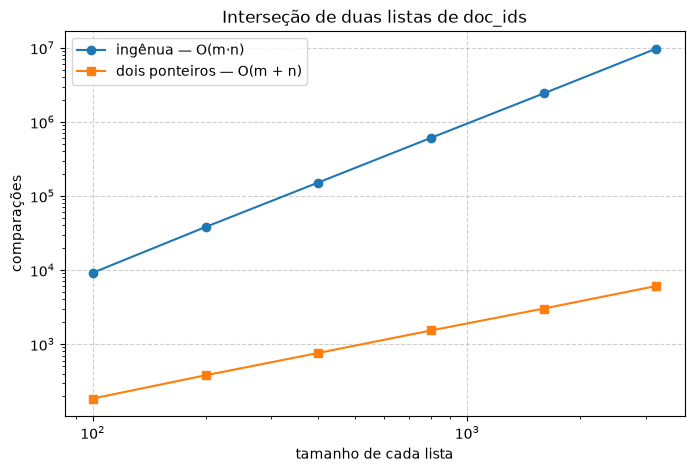

In [17]:
plt.figure(figsize=(8, 5))
plt.plot(otim1["tamanho de cada lista"], otim1["ingenua"], marker="o", label="ingênua — O(m·n)")
plt.plot(otim1["tamanho de cada lista"], otim1["ordenada"], marker="s", label="dois ponteiros — O(m + n)")
plt.xscale("log")
plt.yscale("log")
plt.title("Interseção de duas listas de doc_ids")
plt.xlabel("tamanho de cada lista")
plt.ylabel("comparações")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.show()

`ordenada / n` e `ingenua / n²` ficam estáveis: uma é linear e a outra quadrática, e por isso o ganho cresce com o tamanho. O resultado é o mesmo nas duas.

### Otimização 2: poda por tamanho na sugestão

A distância de edição é no mínimo a diferença de tamanho entre as palavras. Então a sugestão agrupa o vocabulário por tamanho, olha primeiro os termos de tamanho parecido e para quando a diferença de tamanho passa da melhor distância já encontrada. Meço com erros de digitação de palavras do vocabulário, que é o uso real:

In [18]:
def palavra_aleatoria():
    return "".join(random.choice("abcdefghijlmnoprstuv") for _ in range(random.randint(3, 14)))


def com_erro_de_digitacao(palavra):
    i = random.randrange(len(palavra))
    return palavra[:i] + random.choice("abcdefghijlmnoprstuv") + palavra[i + 1:]


class VocabularioSimples:
    """Só o que `sugerir` usa: um objeto com .termos.in_order()."""
    def __init__(self, palavras):
        self.termos = BSTTermos()
        for p in palavras:
            self.termos.insert(p)


linhas = []
for tamanho in [200, 400, 800, 1600]:
    palavras = [palavra_aleatoria() for _ in range(tamanho)]
    vocab = VocabularioSimples(palavras)
    consultas = [com_erro_de_digitacao(random.choice(palavras)) for _ in range(4)]
    sem = com = 0
    for termo in consultas:
        s1, d1, c_sem = sugerir(termo, vocab, podar=False)
        s2, d2, c_com = sugerir(termo, vocab, podar=True)
        assert (s1, d1) == (s2, d2)                     # a poda não muda a resposta
        sem, com = sem + c_sem, com + c_com
    linhas.append({"vocabulário": vocab.termos.tamanho, "distâncias sem poda": sem,
                   "distâncias com poda": com, "evitadas": f"{1 - com / sem:.0%}",
                   "ganho": sem / com})
otim2 = pd.DataFrame(linhas)
otim2

,vocabulário,distâncias sem poda,distâncias com poda,evitadas,ganho
0,199,796,185,77%,4.302703
1,400,1600,296,82%,5.405405
2,800,3200,828,74%,3.864734
3,1600,6400,1457,77%,4.392588


A poda não muda a resposta e evita a maior parte dos cálculos, numa fração estável: é ganho de constante (a sugestão continua O(V·L²)).

## 10. Análise de custos

D documentos, T termos no total, V termos distintos, h a altura da BST, L o tamanho de um termo e r o número de resultados:

- indexação: O(T + V·h). Cada termo é O(1) na hashtable e na lista, e cada termo novo ainda desce a BST.
- consulta: O(q + soma dos tamanhos das listas). O shunting-yard percorre os q tokens e as operações são lineares nas listas.
- ranqueamento: O(soma dos tamanhos das listas + r log r).
- sugestão: O(V·L²), uma distância de edição por termo do vocabulário.
- relatório BFS: O(V).

### Relatório de desempenho

As quatro etapas num corpus sintético maior, dobrando o número de documentos:

In [19]:
def corpus_sintetico(qtd, vocabulario, palavras_por_doc=40):
    return [" ".join(random.choice(vocabulario) for _ in range(palavras_por_doc)) for _ in range(qtd)]


base = [palavra_aleatoria() for _ in range(400)]
linhas = []
for qtd in [100, 200, 400, 800]:
    docs = corpus_sintetico(qtd, base)

    t_indexar = float("inf")
    for _ in range(3):                       # melhor de 3: ruído de máquina só aumenta o tempo
        inicio = time.perf_counter()
        idx = IndiceInvertido(docs)
        t_indexar = min(t_indexar, time.perf_counter() - inicio)

    a, b, c = base[0], base[1], base[2]
    inicio = time.perf_counter()
    resultado, _, comparacoes_consulta = consultar(f"({a} OR {b}) AND NOT {c}", idx)
    t_consultar = time.perf_counter() - inicio

    t_ranquear = t_sugerir = float("inf")
    for _ in range(3):
        inicio = time.perf_counter()
        ranking, _ = buscar(f"{a} OR {b}", idx)
        t_ranquear = min(t_ranquear, time.perf_counter() - inicio)
        inicio = time.perf_counter()
        _, _, distancias = sugerir(a[:-1] + "x", idx)
        t_sugerir = min(t_sugerir, time.perf_counter() - inicio)

    linhas.append({"documentos": qtd, "termos (T)": idx.total_tokens, "vocabulário (V)": idx.termos.tamanho,
                   "indexar_ms": t_indexar * 1000, "indexar_µs_por_termo": t_indexar / idx.total_tokens * 1e6,
                   "consulta_comparacoes": comparacoes_consulta, "consulta_ms": t_consultar * 1000,
                   "resultados (r)": len(ranking), "ranquear_ms": t_ranquear * 1000,
                   "sugerir_distancias": distancias, "sugerir_ms": t_sugerir * 1000})

relatorio = pd.DataFrame(linhas)
relatorio

,documentos,termos (T),vocabulário (V),indexar_ms,indexar_µs_por_termo,consulta_comparacoes,consulta_ms,resultados (r),ranquear_ms,sugerir_distancias,sugerir_ms
0,100,4000,400,26.8166,6.704150,124,0.0891,15,0.0824,106,45.3123
1,200,8000,400,51.7681,6.471013,268,0.1067,40,0.1348,106,43.9559
2,400,16000,400,109.2870,6.830437,519,0.1797,83,0.2654,106,45.7787
3,800,32000,400,280.0100,8.750313,1007,0.4417,125,0.4888,106,45.9310


- Indexação: o tempo por termo fica na mesma faixa enquanto T cresce 8 vezes, então ela é linear.
- Consulta: as comparações crescem na mesma proporção que os documentos, porque as listas crescem junto.
- Ranqueamento: cresce com o número de resultados. Na primeira versão ele crescia mais rápido, porque para cada documento a pontuação percorria a lista do termo inteira (O(D²)); troquei por uma passada só em cada lista.
- Sugestão: depende só do vocabulário, que ficou fixo em 400; o número de distâncias calculadas é o mesmo em todas as linhas.

O gargalo é a sugestão, O(V·L²). Com um vocabulário muito grande, o próximo passo seria indexar os termos por pedaços de 2 ou 3 letras e só comparar com os termos que compartilham pedaços com o digitado.

## 11. Casos de borda

In [20]:
invalidas = ["", "   ", "busca AND", "AND busca", "(busca OR fila", "busca OR fila)", "busca fila", "NOT"]
for consulta in invalidas:
    try:
        consultar(consulta, indice)
        raise AssertionError(f"deveria recusar {consulta!r}")
    except ConsultaInvalidaError as erro:
        print(f"{consulta!r:<18} → {erro}")

# termo inexistente dá lista vazia, não erro; e combina normalmente
assert consultar("inexistente", indice)[0] == []
assert consultar("inexistente OR fila", indice)[0] == consultar("fila", indice)[0]
assert consultar("NOT inexistente", indice)[0] == list(range(len(DOCUMENTOS)))

# acento e maiúscula na consulta não atrapalham
assert consultar("BINÁRIA", indice)[0] == consultar("binaria", indice)[0]

# índice de coleção vazia
vazio = IndiceInvertido([])
assert vazio.termos.tamanho == 0 and consultar("qualquer", vazio)[0] == []

# ranqueamento com um resultado só e sem resultado
assert len(buscar("quicksort", indice)[0]) == 1
assert buscar("inexistente", indice)[0] == []

# sugestão para um termo que existe: distância 0, ele mesmo
assert sugerir("fila", indice)[:2] == ("fila", 0)

print("\ntodos os casos de borda passaram")

''                 → consulta vazia
'   '              → consulta vazia
'busca AND'        → AND precisa de um termo de cada lado
'AND busca'        → AND precisa de um termo de cada lado
'(busca OR fila'   → tem '(' sem o ')' correspondente
'busca OR fila)'   → ')' na posição 4 não tem '(' correspondente
'busca fila'       → falta um operador entre 'busca' e 'fila' (posição 2)
'NOT'              → NOT sem termo depois dele

todos os casos de borda passaram


## 12. As oito peças obrigatórias

Confiro que cada peça exigida pelo enunciado está no caminho que o motor usa:

In [21]:
cont = {"comparacoes": 0, "chamadas": 0}
quicksort([((1, 0), 0), ((0, 1), 1), ((2, 2), 2)], cont)

memo = HashTableChained()
distancia_edicao("fila", "filha", {"chamadas": 0}, memo)

pecas = [
    ("hashtable", "índice invertido: termo → lista", isinstance(indice.tabela, HashTableChained)),
    ("lista encadeada", "ocorrências (doc_id, posições)", isinstance(indice.tabela.get("busca"), ListaOcorrencias)),
    ("árvore", "BST de termos", isinstance(indice.termos, BSTTermos) and indice.termos.tamanho > 0),
    ("pilha", "shunting-yard e avaliação", para_posfixa(["a", "AND", "b"]) == ["a", "b", "AND"]),
    ("fila", "BFS do relatório de diagnóstico", len(relatorio_bfs(indice.termos)["por_nivel"]) > 1),
    ("recursão", "BST, QuickSort e distância de edição", cont["chamadas"] > 1),
    ("programação dinâmica", "distância de edição com memo", len(memo) > 0),
    ("ordenação eficiente", "QuickSort no ranqueamento", cont["comparacoes"] > 0),
]
for nome, onde, ok in pecas:
    assert ok, nome
pd.DataFrame(pecas, columns=["peça", "onde é usada", "conferida"])

,peça,onde é usada,conferida
0,hashtable,índice invertido: termo → lista,True
1,lista encadeada,"ocorrências (doc_id, posições)",True
2,árvore,BST de termos,True
3,pilha,shunting-yard e avaliação,True
4,fila,BFS do relatório de diagnóstico,True
5,recursão,"BST, QuickSort e distância de edição",True
6,programação dinâmica,distância de edição com memo,True
7,ordenação eficiente,QuickSort no ranqueamento,True
